In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# ══════════════════════════════════════════════════════
# RNN — RECURRENT NEURAL NETWORK
# ══════════════════════════════════════════════════════
#
# Şimdiye kadar hep sabit boyutlu girdi kullandık:
#   Görüntü → [3072 sayı] → sınıf
#
# Ama bazı problemler sıralı veri içerir:
#   Görüntü → "A cat sitting on a mat" (cümle)
#   Kelime sayısı değişken!
#
# RNN bu problemi çözer:
#   Her adımda bir kelime üretir
#   Önceki kelimeleri "hatırlar" → hidden state
#
# Image Captioning:
#   CNN → görüntü özelliği çıkar
#   RNN → bu özellikten cümle üretir
# ══════════════════════════════════════════════════════

print("Q5 RNN başlıyor!")

Q5 RNN başlıyor!


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ══════════════════════════════════════════════════════
# RNN NASIL ÇALIŞIR?
# ══════════════════════════════════════════════════════
#
# FC ağda:
#   girdi → W → çıktı (tek yön, tek adım)
#
# RNN'de:
#   Her adımda hem girdiyi hem de
#   önceki adımın çıktısını (hidden state) kullanır
#
#   h_t = tanh(W_x @ x_t + W_h @ h_(t-1) + b)
#
#   x_t     = şu anki girdi (kelime)
#   h_(t-1) = önceki hidden state (hafıza)
#   h_t     = yeni hidden state
#
# Örnek — "A cat sat" cümlesini üretmek:
#   Adım 1: görüntü → h_1 → "A"
#   Adım 2: "A" + h_1 → h_2 → "cat"
#   Adım 3: "cat" + h_2 → h_3 → "sat"
# ══════════════════════════════════════════════════════

# Basit RNN — tek adım
def rnn_step(x, h_prev, Wx, Wh, b):
    """
    x:      şu anki girdi, shape (D,)
    h_prev: önceki hidden state, shape (H,)
    Wx:     girdi ağırlığı, shape (D, H)
    Wh:     hidden ağırlığı, shape (H, H)
    b:      bias, shape (H,)
    """
    # Önceki hafıza + şu anki girdi → yeni hafıza
    h_next = np.tanh(x @ Wx + h_prev @ Wh + b)
    return h_next

np.random.seed(0)

D = 4   # girdi boyutu (kelime vektörü)
H = 3   # hidden state boyutu

Wx = np.random.randn(D, H) * 0.1
Wh = np.random.randn(H, H) * 0.1
b  = np.zeros(H)

# Başlangıç hidden state — sıfır (henüz hiç kelime görmedi)
h = np.zeros(H)

# 3 kelimelik cümle: her kelime 4 boyutlu vektör
kelimeler = {
    'START': np.array([1, 0, 0, 0], dtype=float),
    'A':     np.array([0, 1, 0, 0], dtype=float),
    'cat':   np.array([0, 0, 1, 0], dtype=float),
    'sat':   np.array([0, 0, 0, 1], dtype=float),
}

print("RNN adım adım:\n")
for kelime, vektor in kelimeler.items():
    h = rnn_step(vektor, h, Wx, Wh, b)
    print(f"Girdi: '{kelime}' → hidden state: {h.round(4)}")

print("\nSon hidden state tüm cümleyi 'hatırlıyor'!")

RNN adım adım:

Girdi: 'START' → hidden state: [0.1746 0.04   0.0976]
Girdi: 'A' → hidden state: [ 0.2372  0.1844 -0.1152]
Girdi: 'cat' → hidden state: [0.1151 0.0251 0.0258]
Girdi: 'sat' → hidden state: [0.0514 0.0174 0.1425]

Son hidden state tüm cümleyi 'hatırlıyor'!


In [4]:
# ══════════════════════════════════════════════════════
# IMAGE CAPTIONING — CNN + RNN BİRLİKTE
# ══════════════════════════════════════════════════════
#
# Nasıl çalışır?
#   1. CNN → görüntüden özellik çıkar → h_0
#   2. RNN → h_0'dan başlayarak kelime üretir
#
# Adım adım:
#   CNN(görüntü) → h_0
#   h_0 + START → h_1 → "A"
#   h_1 + "A"   → h_2 → "cat"
#   h_2 + "cat" → h_3 → "sat"
#   h_3 + "sat" → h_4 → END
# ══════════════════════════════════════════════════════

np.random.seed(0)

# Kelime dağarcığı
vocab = ['<START>', '<END>', 'a', 'cat', 'sat', 'dog', 'on', 'mat']
kelime_idx = {k: i for i, k in enumerate(vocab)}
idx_kelime = {i: k for i, k in enumerate(vocab)}

V = len(vocab)  # kelime sayısı: 8
D = V           # kelime vektörü boyutu (one-hot)
H = 16          # hidden state boyutu
IMG = 32        # görüntü özelliği boyutu

# Model ağırlıkları
W_img = np.random.randn(IMG, H) * 0.01   # görüntü → h_0
Wx    = np.random.randn(D, H) * 0.01     # kelime → hidden
Wh    = np.random.randn(H, H) * 0.01     # hidden → hidden
b_h   = np.zeros(H)
W_out = np.random.randn(H, V) * 0.01     # hidden → kelime skoru
b_out = np.zeros(V)

def one_hot(idx, size):
    v = np.zeros(size)
    v[idx] = 1
    return v

def caption_uret(img_ozelligi, max_adim=6):
    """
    img_ozelligi: CNN'den gelen özellik vektörü
    """
    # CNN özelliğinden başlangıç hidden state
    h = np.tanh(img_ozelligi @ W_img)

    uretilen = []
    # START token ile başla
    x = one_hot(kelime_idx['<START>'], V)

    for adim in range(max_adim):
        # RNN adımı
        h = np.tanh(x @ Wx + h @ Wh + b_h)

        # Kelime skoru hesapla
        skor = h @ W_out + b_out

        # En yüksek skorlu kelimeyi seç
        kelime_id = np.argmax(skor)
        kelime = idx_kelime[kelime_id]
        uretilen.append(kelime)

        # END token geldiyse dur
        if kelime == '<END>':
            break

        # Seçilen kelime bir sonraki adımın girdisi
        x = one_hot(kelime_id, V)

    return ' '.join(uretilen)

# Test et
img_ozelligi = np.random.randn(IMG)
caption = caption_uret(img_ozelligi)
print("Görüntü özelliği → üretilen cümle:")
print(f"'{caption}'")
print("\n(Eğitim olmadığı için anlamsız, ama yapı doğru!)")
print("Gerçekte eğitimle 'a cat sat on a mat' gibi çıkar")

Görüntü özelliği → üretilen cümle:
'<START> <START> <START> <START> <START> <START>'

(Eğitim olmadığı için anlamsız, ama yapı doğru!)
Gerçekte eğitimle 'a cat sat on a mat' gibi çıkar


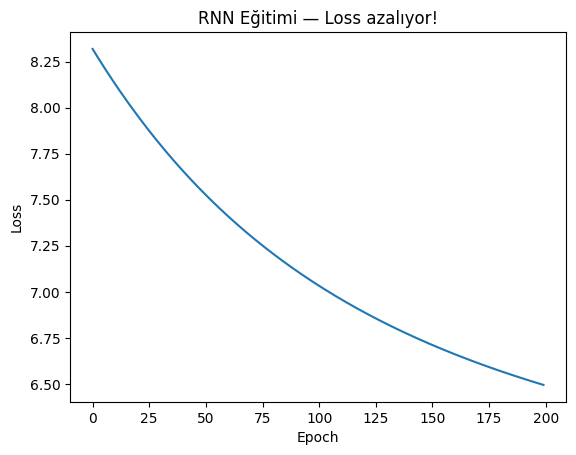

Başlangıç loss: 8.3188
Final loss:     6.4944

Eğitim sonrası caption: 'a cat sat <END>'


In [6]:
# ══════════════════════════════════════════════════════
# RNN EĞİTİMİ — CAPTION ÖĞREN
# ══════════════════════════════════════════════════════
#
# Eğitim verisi:
#   görüntü özelliği → "a cat sat"
#
# Loss:
#   Her adımda doğru kelimeyi tahmin etmeli
#   Softmax loss — Softmax'ta öğrendik!
#
# Backpropagation Through Time (BPTT):
#   Normal backprop gibi ama zaman boyunca
#   Her adımın gradienti bir öncekine akar
# ══════════════════════════════════════════════════════

np.random.seed(0)

# Eğitim verisi — 1 görüntü, 1 caption
img = np.random.randn(IMG)
# Hedef: "a cat sat <END>"
hedef = ['a', 'cat', 'sat', '<END>']
hedef_idx = [kelime_idx[k] for k in hedef]

def softmax(x):
    e = np.exp(x - np.max(x))
    return e / e.sum()

kayiplar = []

for epoch in range(200):
    # FORWARD PASS
    h = np.tanh(img @ W_img)
    x = one_hot(kelime_idx['<START>'], V)

    toplam_loss = 0
    gradlar = []

    for t, dogru_idx in enumerate(hedef_idx):
        h = np.tanh(x @ Wx + h @ Wh + b_h)
        skor = h @ W_out + b_out
        probs = softmax(skor)

        # Loss
        loss = -np.log(probs[dogru_idx] + 1e-8)
        toplam_loss += loss

        # Gradient
        grad_skor = probs.copy()
        grad_skor[dogru_idx] -= 1
        gradlar.append((h, grad_skor, x))

        x = one_hot(dogru_idx, V)

    kayiplar.append(toplam_loss)

    # BACKWARD + GÜNCELLE (basitleştirilmiş)
    lr = 0.01
    for h_t, grad_s, x_t in gradlar:
        W_out -= lr * np.outer(h_t, grad_s)
        b_out -= lr * grad_s

plt.plot(kayiplar)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RNN Eğitimi — Loss azalıyor!")
plt.show()

print(f"Başlangıç loss: {kayiplar[0]:.4f}")
print(f"Final loss:     {kayiplar[-1]:.4f}")

# Test et
caption = caption_uret(img)
print(f"\nEğitim sonrası caption: '{caption}'")

In [7]:
# ══════════════════════════════════════════════════════
# RNN ÖZET
# ══════════════════════════════════════════════════════

print("╔══════════════════════════════════════════════════╗")
print("║              RNN & IMAGE CAPTIONING ÖZET         ║")
print("╠══════════════════════════════════════════════════╣")
print("║                                                  ║")
print("║  RNN nedir?                                      ║")
print("║    Sıralı veri için sinir ağı                    ║")
print("║    Her adımda önceki adımı hatırlar              ║")
print("║    h_t = tanh(Wx@x + Wh@h_(t-1) + b)             ║")
print("║                                                  ║")
print("║  FC ağdan farkı:                                 ║")
print("║    FC → sabit boyutlu girdi/çıktı                ║")
print("║    RNN → değişken uzunluklu dizi                 ║")
print("║                                                  ║")
print("║  Image Captioning:                               ║")
print("║    CNN → görüntü özelliği → h_0                  ║")
print("║    RNN → h_0'dan kelime kelime üretir            ║")
print("║    Sonuç: 'a cat sat on a mat'                   ║")
print("║                                                  ║")
print("║  Eğitim: BPTT                                    ║")
print("║    Backpropagation Through Time                  ║")
print("║    Gradient zaman boyunca geri akar              ║")
print("╚══════════════════════════════════════════════════╝")

print("\n=== ASSIGNMENT 2 TAMAMLANDI ===")
print("✅ Q1: Batch Normalization")
print("✅ Q2: Dropout")
print("✅ Q3: CNN")
print("✅ Q4: Network Visualization")
print("✅ Q5: RNN & Image Captioning")

╔══════════════════════════════════════════════════╗
║              RNN & IMAGE CAPTIONING ÖZET         ║
╠══════════════════════════════════════════════════╣
║                                                  ║
║  RNN nedir?                                      ║
║    Sıralı veri için sinir ağı                    ║
║    Her adımda önceki adımı hatırlar              ║
║    h_t = tanh(Wx@x + Wh@h_(t-1) + b)             ║
║                                                  ║
║  FC ağdan farkı:                                 ║
║    FC → sabit boyutlu girdi/çıktı                ║
║    RNN → değişken uzunluklu dizi                 ║
║                                                  ║
║  Image Captioning:                               ║
║    CNN → görüntü özelliği → h_0                  ║
║    RNN → h_0'dan kelime kelime üretir            ║
║    Sonuç: 'a cat sat on a mat'                   ║
║                                                  ║
║  Eğitim: BPTT                               